<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/new_hcf_simulatio%E3%85%8C%E3%84%B4n_paper_by_paper_report_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# new_hcf_simulation_paper_by_paper_report

각 논문을 별도 셀에서 하나씩 실행하는 검증 보고서입니다. 각 섹션은 입력값의 선택 이유, 논문값, 코드값, 점별 오차율, MAPE/RMSE, 비교 그래프를 출력합니다.

`###` Poggiolini, `$$$` Nespola, `%%%` Carena, `@@@` Petrovich, `CUSTOM` 사용자 입력 HCF입니다. 논문 출력값을 모델 계수에 직접 피팅하지 않습니다.

In [1]:
# 0. 공통 설정: 이 셀과 마지막 main 셀의 PAPER_CODE만 바꾸면 됩니다.
from dataclasses import dataclass, asdict
from pathlib import Path
import json, math, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfcinv

RESULTS = Path("new_hcf_general_results")
RESULTS.mkdir(exist_ok=True)
C0 = 299_792_458.0
H = 6.626_070_15e-34
U01 = 2.4048255577
DB_PER_NEPER = 10.0/np.log(10.0)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":180,"axes.grid":True,"grid.alpha":0.25,"font.size":10})

PAPER_CODE = "ALL"  # ### / $$$ / %%% / @@@ / CUSTOM / ALL
CARENA_REFERENCE_CSV = None  # e.g. "carena_reference.csv"
CARENA_PREDICTION_CSV = None # e.g. "carena_predictions.csv"

def db2lin(x): return 10.0**(np.asarray(x,dtype=float)/10.0)
def dbm2w(x): return 1e-3*db2lin(x)
def w2dbm(x): return 10*np.log10(np.asarray(x,dtype=float)/1e-3)
def signed_error_pct(model, reference): return 100.0*(np.asarray(model,dtype=float)/np.asarray(reference,dtype=float)-1.0)
def error_metrics(model, reference):
    e=signed_error_pct(model,reference); d=np.asarray(model,dtype=float)-np.asarray(reference,dtype=float)
    return {"MAPE_percent":float(np.mean(np.abs(e))),"RMSE":float(np.sqrt(np.mean(d*d))),"MAE":float(np.mean(np.abs(d))),"MAX_APE_percent":float(np.max(np.abs(e)))}
def save_table(name, df):
    df.to_csv(RESULTS/f"{name}.csv",index=False)
    print(f"\n{name}"); print(df.to_string(index=False))
def save_fig(name, fig):
    fig.savefig(RESULTS/f"{name}.png",bbox_inches="tight"); fig.savefig(RESULTS/f"{name}.svg",bbox_inches="tight"); plt.show()

@dataclass(frozen=True)
class SystemConfig:
    wavelength_nm: float=1550.0
    symbol_rate_baud: float=32e9
    channel_spacing_hz: float=32e9
    n_channels: int=157
    span_km: float=100.0
    n_spans: int=1
    nf_db: float=5.0
    trx_snr_db: float=20.0
    ber_target: float=1.5e-2
    b2b_penalty_db: float=2.5

@dataclass(frozen=True)
class Fiber:
    name: str
    alpha_db_km: float
    D_ps_nm_km: float
    gamma_W_inv_km: float

def beta2_s2_per_km(D_ps_nm_km, wavelength_nm=1550.0):
    # D [ps/(nm km)] -> beta2 [s^2/km]
    return abs(-((wavelength_nm*1e-9)**2/(2*np.pi*C0))*(np.asarray(D_ps_nm_km)*1e-6)*1000.0)

def gn_eta_eq13(fiber, system):
    b=beta2_s2_per_km(fiber.D_ps_nm_km,system.wavelength_nm); a=fiber.alpha_db_km/8.685889638
    Le=(1-np.exp(-2*a*system.span_km))/(2*a); Li=1/(2*a)
    arg=0.5*np.pi**2*b*Li*(system.n_channels*system.symbol_rate_baud)**2
    return 8/27*fiber.gamma_W_inv_km**2*Le**2/(np.pi*b*Li*system.symbol_rate_baud**2)*np.arcsinh(arg)

def gn_eta_legacy(fiber, system):
    b=beta2_s2_per_km(fiber.D_ps_nm_km,system.wavelength_nm); a=fiber.alpha_db_km/8.685889638
    arg=np.pi**2*b*system.symbol_rate_baud**2/(4*a)*system.n_channels**(2*system.symbol_rate_baud/system.channel_spacing_hz)
    return system.n_spans*4*fiber.gamma_W_inv_km**2/(27*np.pi*b*a*system.symbol_rate_baud**2)*np.arcsinh(arg)

def ase_per_span_w(fiber, system):
    gain_lin=db2lin(fiber.alpha_db_km*system.span_km)
    return H*C0/(system.wavelength_nm*1e-9)*system.symbol_rate_baud*db2lin(system.nf_db)*(gain_lin-1.0)

def snr_gsnr_curve(fiber, system, launch_dbm):
    p=dbm2w(launch_dbm); eta=gn_eta_eq13(fiber,system)
    ase=system.n_spans*ase_per_span_w(fiber,system); nli=system.n_spans*eta*p**3
    trx=p/db2lin(system.trx_snr_db)
    gsnr=p/(ase+nli); snr=p/(ase+nli+trx)
    throughput=system.n_channels*2.0*system.symbol_rate_baud*np.log2(1.0+snr)/1e12
    return snr,gsnr,throughput

def hcf_gamma_from_n2(n2_m2_w, Aeff_um2, wavelength_nm=1550.0):
    return 2*np.pi*n2_m2_w/(wavelength_nm*1e-9*(Aeff_um2*1e-12))*1000.0

print("Initialized general GN/HCF engine; PAPER_CODE =", PAPER_CODE)

Initialized general GN/HCF engine; PAPER_CODE = ALL


## 1. HCF geometry engine

기본 geometry는 Hasan effective-radius + Marcatili–Schmeltzer 근사입니다. 이 모델은 후보 구조 선별용이며 full-vector FEM을 대체하지 않습니다.

In [2]:
@dataclass(frozen=True)
class DNANFGeometry:
    core_radius_um: float=14.75
    membrane_thickness_um: float=0.50
    outer_tube_diameter_um: float=31.05
    tube_count: int=5
    nesting_order: int=2
    @property
    def core_radius_m(self): return self.core_radius_um*1e-6
    @property
    def membrane_thickness_m(self): return self.membrane_thickness_um*1e-6
    @property
    def perimeter_gap_m(self):
        th=np.pi/self.tube_count
        return 2*self.core_radius_m*np.sin(th)-self.outer_tube_diameter_um*1e-6*(1-np.sin(th))

def hasan_coefficients(g):
    q=g.core_radius_m/g.perimeter_gap_m; n=g.tube_count; N=g.nesting_order
    f1=1.095*np.exp(.097041/q)
    f2=.007584*n*np.exp(.76246/q)-.002*n+.012+.0045*np.exp(-4.1589/(N*q))
    return float(f1),float(f2)

def hcf_neff(wavelength_m, g, f1=None, f2=None):
    if f1 is None or f2 is None: f1,f2=hasan_coefficients(g)
    re=f1*g.core_radius_m*(1-f2*wavelength_m**2/(g.core_radius_m*g.membrane_thickness_m))
    return 1.0-.125*(U01*wavelength_m/(np.pi*re))**2

def hcf_dispersion(wavelength_nm, g, step_nm=.2):
    w=np.asarray(wavelength_nm,dtype=float)*1e-9; h=step_nm*1e-9; f1,f2=hasan_coefficients(g)
    n=lambda off:hcf_neff(w+off,g,f1,f2)
    d2=(-n(2*h)+16*n(h)-30*n(0)+16*n(-h)-n(-2*h))/(12*h*h)
    return (-(w/C0)*d2)/1e-6

def silica_index(wavelength_m):
    u=np.asarray(wavelength_m)*1e6; us=u*u; B=[.6961663,.4079426,.8974794]; C=[.0684043,.1162414,9.896161]; ns=np.ones_like(us)
    for b,c in zip(B,C): ns += b*us/(us-c*c)
    return np.sqrt(ns)

def hcf_raw_leakage_db_km(wavelength_nm,g):
    w=np.asarray(wavelength_nm,dtype=float)*1e-9; k0=2*np.pi/w; r=g.core_radius_m; t=g.membrane_thickness_m; kap=U01/r; ns=silica_index(w); sig=k0*np.sqrt(ns**2-1); ph=sig*t
    te=4*np.cos(ph)**2+(kap/sig+sig/kap)**2*np.sin(ph)**2
    tm=4*np.cos(ph)**2+(ns**2*kap/sig+sig/(ns**2*kap))**2*np.sin(ph)**2
    return .5*(2*U01/(r*r*k0*te)+2*U01/(r*r*k0*tm))*DB_PER_NEPER*1000.0

def hcf_fiber_from_geometry(g, alpha_total_db_km=.10, n2_m2_w=3.0e-23, Aeff_um2=300.0, wavelength_nm=1550.0):
    D=float(hcf_dispersion(np.array([wavelength_nm]),g)[0]); gamma=hcf_gamma_from_n2(n2_m2_w,Aeff_um2,wavelength_nm)
    return Fiber("HCF-DNANF",float(alpha_total_db_km),D,gamma)

print("HCF geometry functions ready; nominal Hasan coefficients =",hasan_coefficients(DNANFGeometry()))

HCF geometry functions ready; nominal Hasan coefficients = (1.128202734589146, 0.0523236730052864)


## 논문별 입력값 선정 이유

### 1. Poggiolini GN
32 GBd, 157 channels, 32 GHz spacing, 100 km span을 사용합니다. 이는 GN Eq.13 계산에 필요한 baud rate, channel count, spacing, span, alpha, dispersion, gamma가 명시되는 대표 uncompensated WDM 링크 조건입니다. 결과는 이론식 구현 검산으로 분류합니다.

### 2. Nespola 7-fiber PM-16QAM
Table I의 alpha, (D), gamma, span, splice loss를 그대로 사용하고, 논문 시스템 조건 15.625 GBaud, 16 GHz spacing, 22 channels, NF 5.5 dB, B2B 기준 17.7 dB를 적용합니다. 실험 Lmax를 계산 후 비교하며 피팅하지 않습니다.

### 3. Carena JLT 2012
PM-BPSK/QPSK/8QAM/16QAM의 동일 비교에는 정확한 span, alpha, dispersion, gamma, NF, BER/FEC threshold, spacing, marker 값이 필요합니다. 현재 값이 모두 확보되지 않아 기본 실행은 검증 보류입니다. 검증된 CSV를 넣은 경우만 계산합니다.

### 4. Petrovich HCF
nominal HCF2 geometry를 Hasan effective-radius와 Marcatili–Schmeltzer 근사에 넣어 Raw 분산을 계산합니다. FEM 분산은 피팅하지 않고 비교합니다. 손실은 leakage proxy와 측정 총손실의 물리적 층이 달라 별도 진단합니다.

### 5. CUSTOM
코어 직경, 막 두께, tube geometry, 총손실, (n_2), (A_{eff}), span, NF, TRX SNR을 변경해 분산·gamma·GN eta·SNR·GSNR·throughput을 계산합니다.

In [3]:
POGGIOLINI_FIBERS=[Fiber("LPSCF",.165,20.4,.8),Fiber("SMF",.2,16.5,1.3),Fiber("NZDSF",.2,3.9,1.6)]
POGGIOLINI_SYSTEM=SystemConfig(wavelength_nm=1550.,symbol_rate_baud=32e9,channel_spacing_hz=32e9,n_channels=157,span_km=100.,n_spans=1,nf_db=5.,trx_snr_db=20.)

NESPOLA=pd.DataFrame([
 ["SSMF",.190,75.,1.26,16.84,51.06,1940.,0.,-7.5],
 ["NZDSF",.200,43.,2.00,2.58,50.18,602.,2.0,-10.0],
 ["PSCF80",.164,86.,1.04,16.36,54.44,2395.,.3,-7.7],
 ["PSCF110",.161,111.,.81,20.50,53.18,3084.,.4,-6.8],
 ["PSCF130",.162,131.,.68,20.92,54.42,3374.,.6,-5.6],
 ["PSCF150",.161,150.,.59,20.69,54.44,3810.,.6,-6.0],
 ["DCF",.457,16.8,6.03,-166.47,20.11,502.,2.5,-6.8]],
 columns=["fiber","alpha_db_km","Aeff_um2","gamma_W_inv_km","D_ps_nm_km","span_km","paper_Lmax_km","splice_loss_db","paper_Popt_dbm"])
NESPOLA_SYSTEM=SystemConfig(wavelength_nm=1550.,symbol_rate_baud=15.625e9,channel_spacing_hz=16e9,n_channels=22,span_km=50.,n_spans=1,nf_db=5.5,trx_snr_db=20.,ber_target=1.5e-2,b2b_penalty_db=2.5)
PETROVICH_GEOMETRY=DNANFGeometry()
PETROVICH_WL_D=np.array([1310.,1550.,1700.]); PETROVICH_FEM_D=np.array([2.1,3.2,3.7])
PETROVICH_WL_LOSS=np.array([1310.,1550.]); PETROVICH_TOTAL_LOSS=np.array([.128,.091])

print("Loaded paper inputs:",len(POGGIOLINI_FIBERS),"Poggiolini fibers and",len(NESPOLA),"Nespola fibers.")

Loaded paper inputs: 3 Poggiolini fibers and 7 Nespola fibers.


## 3. 검증 함수

각 함수는 `paper` reference를 모델 파라미터 피팅에 사용하지 않고, 계산 후 오차를 구합니다. `validation_type`은 결과를 논문 수준으로 해석할 때의 주의점을 표시합니다.

In [4]:
def run_poggiolini():
    rows=[]
    for f in POGGIOLINI_FIBERS:
        paper=gn_eta_eq13(f,POGGIOLINI_SYSTEM); legacy=gn_eta_legacy(f,POGGIOLINI_SYSTEM)
        rows.append([f.name,paper,legacy,abs(signed_error_pct(legacy,paper))])
    df=pd.DataFrame(rows,columns=["fiber","paper_Eq13_eta","code_legacy_eta","absolute_error_pct"])
    m=error_metrics(df.code_legacy_eta,df.paper_Eq13_eta); save_table("01_poggiolini",df)
    fig,ax=plt.subplots(figsize=(8,4.5)); x=np.arange(len(df)); ax.plot(df.fiber,df.paper_Eq13_eta,'o-',label="Paper Eq.13"); ax.plot(df.fiber,df.code_legacy_eta,'s--',label=f"Code legacy (MAPE {m['MAPE_percent']:.2f}%)"); ax.set_ylabel("eta (1/W²)"); ax.set_title("Poggiolini GN equation check"); ax.legend(); save_fig("01_poggiolini",fig)
    return {"paper":"Poggiolini 2012","MAPE_percent":m["MAPE_percent"],"validation_type":"EQUATION_CHECK","table":df}

def eta_nespola(row):
    b=beta2_s2_per_km(row.D_ps_nm_km,1550.); a=row.alpha_db_km/8.685889638
    arg=np.pi**2*b*NESPOLA_SYSTEM.symbol_rate_baud**2/(4*a)*NESPOLA_SYSTEM.n_channels**(2*NESPOLA_SYSTEM.symbol_rate_baud/NESPOLA_SYSTEM.channel_spacing_hz)
    return 4/27*row.gamma_W_inv_km**2/(np.pi*b*a*NESPOLA_SYSTEM.symbol_rate_baud**2)*np.arcsinh(arg)

def run_nespola():
    threshold=db2lin(17.7); rows=[]
    ps=np.linspace(-14.,-4.,201)
    for _,r in NESPOLA.iterrows():
        gain_db=r.alpha_db_km*r.span_km+r.splice_loss_db
        pase=H*C0/(1550e-9)*db2lin(NESPOLA_SYSTEM.nf_db)*NESPOLA_SYSTEM.symbol_rate_baud*(10**(gain_db/10)-1)
        eta=eta_nespola(r); best=(None,-1,None)
        for p_dbm in ps:
            p=dbm2w(p_dbm); inv=pase/p+eta*p*p; n=max([k for k in range(1,201) if 1/(k*inv)>=threshold],default=0); reach=n*r.span_km
            if reach>best[1]: best=(p_dbm,reach,n)
        rows.append([r.fiber,r.paper_Lmax_km,best[1],abs(signed_error_pct(best[1],r.paper_Lmax_km)),r.paper_Popt_dbm,best[0],best[2],eta])
    df=pd.DataFrame(rows,columns=["fiber","paper_Lmax_km","code_Lmax_km","absolute_error_pct","paper_Popt_dbm","code_Popt_dbm","code_spans","eta_W_inv2"])
    m=error_metrics(df.code_Lmax_km,df.paper_Lmax_km); save_table("02_nespola",df)
    fig,ax=plt.subplots(figsize=(10,4.5)); x=np.arange(len(df)); ax.plot(df.fiber,df.paper_Lmax_km,'o-',label="Paper experiment"); ax.plot(df.fiber,df.code_Lmax_km,'s--',label="Code reconstruction"); ax.set_yscale('log'); ax.set_ylabel("Lmax (km)"); ax.tick_params(axis='x',rotation=35); ax.set_title(f"Nespola PM-16QAM | MAPE {m['MAPE_percent']:.2f}%"); ax.legend(); save_fig("02_nespola",fig)
    return {"paper":"Nespola 2014","MAPE_percent":m["MAPE_percent"],"validation_type":"INPUT_BASED_INDEPENDENT","table":df}

def run_petrovich():
    codeD=hcf_dispersion(PETROVICH_WL_D,PETROVICH_GEOMETRY); codeL=hcf_raw_leakage_db_km(PETROVICH_WL_LOSS,PETROVICH_GEOMETRY)
    ddf=pd.DataFrame({"wavelength_nm":PETROVICH_WL_D,"paper_FEM_D":PETROVICH_FEM_D,"code_raw_D":codeD,"absolute_error_pct":abs(signed_error_pct(codeD,PETROVICH_FEM_D))})
    ldf=pd.DataFrame({"wavelength_nm":PETROVICH_WL_LOSS,"paper_total_loss_db_km":PETROVICH_TOTAL_LOSS,"code_raw_leakage_proxy_db_km":codeL,"absolute_error_pct":abs(signed_error_pct(codeL,PETROVICH_TOTAL_LOSS))})
    dm=error_metrics(codeD,PETROVICH_FEM_D); lm=error_metrics(codeL,PETROVICH_TOTAL_LOSS); save_table("03_petrovich_dispersion",ddf); save_table("04_petrovich_loss_audit",ldf)
    fig,ax=plt.subplots(1,2,figsize=(12,4.5)); ax[0].plot(PETROVICH_WL_D,PETROVICH_FEM_D,'o-',label="Petrovich FEM"); ax[0].plot(PETROVICH_WL_D,codeD,'s--',label=f"Raw geometry (MAPE {dm['MAPE_percent']:.2f}%)"); ax[0].set(xlabel="Wavelength (nm)",ylabel="D (ps/(nm km))",title="Petrovich dispersion"); ax[0].legend(fontsize=8); ax[1].semilogy(PETROVICH_WL_LOSS,PETROVICH_TOTAL_LOSS,'o-',label="Measured total"); ax[1].semilogy(PETROVICH_WL_LOSS,codeL,'s--',label="Raw leakage proxy"); ax[1].set(xlabel="Wavelength (nm)",ylabel="Loss (dB/km)",title="Loss: NOT COMPARABLE"); ax[1].legend(fontsize=8); save_fig("03_petrovich",fig)
    return {"paper":"Petrovich 2025","MAPE_percent":dm["MAPE_percent"],"loss_proxy_MAPE_percent":lm["MAPE_percent"],"validation_type":"RAW_GEOMETRY_INDEPENDENT / LOSS_LAYER_MISMATCH","table":ddf}

def run_carena(reference_csv=None,prediction_csv=None):
    status={"paper":"Carena JLT 2012","validation_type":"INPUTS_UNVERIFIED","MAPE_percent":None,"reason":"Exact panel inputs, BER/FEC threshold and marker outputs are required."}
    if reference_csv is None or prediction_csv is None:
        pd.DataFrame([status]).to_csv(RESULTS/"05_carena_status.csv",index=False); print(status); return status
    ref=pd.read_csv(reference_csv); pred=pd.read_csv(prediction_csv); keys=["panel","modulation","marker_label"]; merged=ref.merge(pred,on=keys,validate="one_to_one")
    merged["absolute_error_pct"]=abs(signed_error_pct(merged.code_value,merged.paper_value)); m=error_metrics(merged.code_value,merged.paper_value); save_table("05_carena_comparison",merged)
    fig,ax=plt.subplots(figsize=(8,5));
    for mod,g in merged.groupby("modulation"): ax.plot(g.spectral_efficiency,g.paper_value,'o-',label=f"{mod} paper"); ax.plot(g.spectral_efficiency,g.code_value,'s--',label=f"{mod} code")
    ax.set_yscale('log'); ax.set_xlabel("Spectral efficiency (bit/s/Hz)"); ax.set_ylabel("Reach (km)"); ax.set_title(f"Carena overlay | MAPE {m['MAPE_percent']:.2f}%"); ax.legend(fontsize=8); save_fig("05_carena",fig)
    status.update({"validation_type":"INPUT_BASED_INDEPENDENT_IF_INPUTS_VERIFIED","MAPE_percent":m["MAPE_percent"]}); return status

print("Validation functions ready.")

Validation functions ready.


## 4. 범용 CUSTOM HCF/광섬유 계산

`CUSTOM_INPUTS`의 geometry, 손실, (n_2), (A_{eff}), span, NF, TRX SNR 등을 바꾸면 분산·GN eta·SNR·GSNR·throughput을 계산합니다. HCF 손실은 Raw leakage proxy가 아니라 사용자가 입력한 `alpha_total_db_km`를 사용합니다. HCF 기본 n2=3.0e-23 m^2/W는 공기/가스 코어 대표값이며, 실리카 유효 비선형성을 사용할 때는 n2·모드 중첩률·Aeff를 별도로 입력하십시오.

In [5]:
CUSTOM_INPUTS={
    "geometry": DNANFGeometry(core_radius_um=14.75,membrane_thickness_um=.50,outer_tube_diameter_um=31.05,tube_count=5,nesting_order=2),
    "alpha_total_db_km": .10, "n2_m2_w": 3.0e-23, "Aeff_um2": 300.0,
    "system": SystemConfig(wavelength_nm=1550.,symbol_rate_baud=95e9,channel_spacing_hz=95e9,n_channels=90,span_km=80.,n_spans=25,nf_db=5.,trx_snr_db=18.)}

def run_custom(custom= CUSTOM_INPUTS):
    g=custom["geometry"]; sys=custom["system"]; fiber=hcf_fiber_from_geometry(g,custom["alpha_total_db_km"],custom["n2_m2_w"],custom["Aeff_um2"],sys.wavelength_nm)
    launch=np.linspace(-20.,30.,251); snr=[]; gsnr=[]; thr=[]
    for p in launch:
        s,gs,t=snr_gsnr_curve(fiber,sys,p); snr.append(10*np.log10(s)); gsnr.append(10*np.log10(gs)); thr.append(t)
    i=int(np.argmax(thr)); summary={"fiber":fiber.name,"D_ps_nm_km":fiber.D_ps_nm_km,"gamma_W_inv_km":fiber.gamma_W_inv_km,"eta_W_inv2":gn_eta_eq13(fiber,sys),"opt_launch_dBm":float(launch[i]),"max_GSNR_dB":float(gsnr[i]),"max_throughput_Tbps":float(thr[i])}
    out=pd.DataFrame({"launch_dBm":launch,"SNR_dB":snr,"GSNR_dB":gsnr,"throughput_Tbps":thr}); save_table("06_custom_launch_sweep",out); (RESULTS/"06_custom_summary.json").write_text(json.dumps(summary,indent=2)); print("CUSTOM SUMMARY",summary)
    fig,ax=plt.subplots(1,2,figsize=(12,4.5)); ax[0].plot(launch,snr,label="SNR"); ax[0].plot(launch,gsnr,label="GSNR"); ax[0].set(xlabel="Launch power (dBm/channel)",ylabel="dB",title="CUSTOM SNR/GSNR"); ax[0].legend(); ax[1].plot(launch,thr,color="#d95f02"); ax[1].set(xlabel="Launch power (dBm/channel)",ylabel="Throughput (Tb/s)",title="CUSTOM throughput"); save_fig("06_custom",fig)
    return summary

def run_all():
    results=[run_poggiolini(),run_nespola(),run_petrovich(),run_carena(),run_custom()]
    rows=[]
    for r in results:
        rows.append({"paper":r.get("paper","CUSTOM"),"validation_type":r.get("validation_type","CUSTOM"),"MAPE_percent":r.get("MAPE_percent"),"status":"see validation_type"})
    summary=pd.DataFrame(rows); save_table("00_summary",summary); (RESULTS/"00_summary.json").write_text(summary.to_json(orient="records",force_ascii=False,indent=2)); return summary

def main(code=PAPER_CODE):
    code=str(code).strip()
    if code=="###": return run_poggiolini()
    if code=="$$$": return run_nespola()
    if code=="%%%": return run_carena(CARENA_REFERENCE_CSV,CARENA_PREDICTION_CSV)
    if code=="@@@": return run_petrovich()
    if code.upper()=="CUSTOM": return run_custom()
    if code.upper()=="ALL": return run_all()
    raise ValueError("PAPER_CODE must be ###, $$$, %%%, @@@, CUSTOM, or ALL")

print("Engine loaded; running paper-by-paper report cells.")

Engine loaded; running paper-by-paper report cells.


## 논문 1 — Poggiolini GN model

`POGGIOLINI_SYSTEM`과 `POGGIOLINI_FIBERS`를 사용합니다. 논문 Eq.13 eta와 코드 eta를 비교합니다.


01_poggiolini
fiber  paper_Eq13_eta  code_legacy_eta  absolute_error_pct
LPSCF      686.562820       718.367263            4.632416
  SMF     1832.692336      1869.903414            2.030405
NZDSF    10290.141722     10499.073280            2.030405


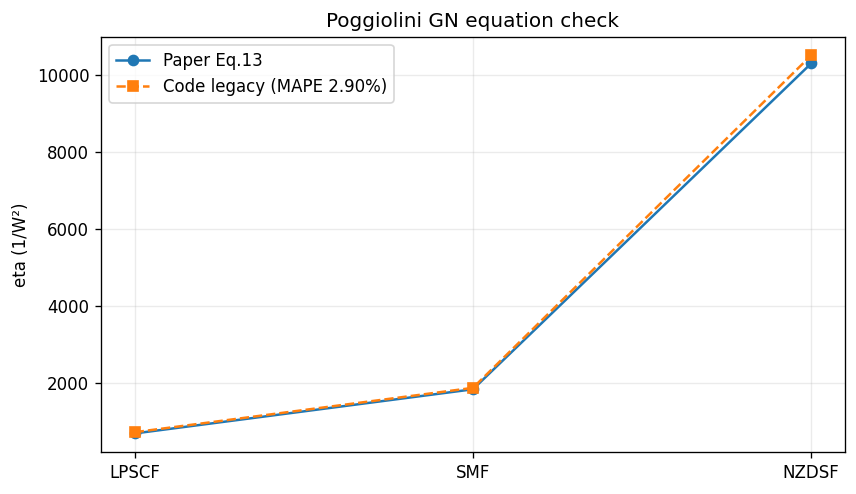

In [6]:
RESULT_POGGIOLINI = run_poggiolini()


## 논문 2 — Nespola 7종 PM-16QAM

Table I fiber 입력과 논문 시스템 조건으로 실험 Lmax를 독립 재계산합니다.


02_nespola
  fiber  paper_Lmax_km  code_Lmax_km  absolute_error_pct  paper_Popt_dbm  code_Popt_dbm  code_spans   eta_W_inv2
   SSMF         1940.0       1889.22            2.617526            -7.5          -7.35          37  4050.055398
  NZDSF          602.0        551.98            8.308970           -10.0         -10.50          11 43623.918704
 PSCF80         2395.0       2286.48            4.531106            -7.7          -7.65          42  3353.147150
PSCF110         3084.0       2978.08            3.434501            -6.8          -6.35          56  1717.311547
PSCF130         3374.0       3156.36            6.450504            -5.6          -5.95          58  1181.219416
PSCF150         3810.0       3484.16            8.552231            -6.0          -5.55          64   904.036746
    DCF          502.0        502.75            0.149402            -6.8          -6.90          25  4789.792914


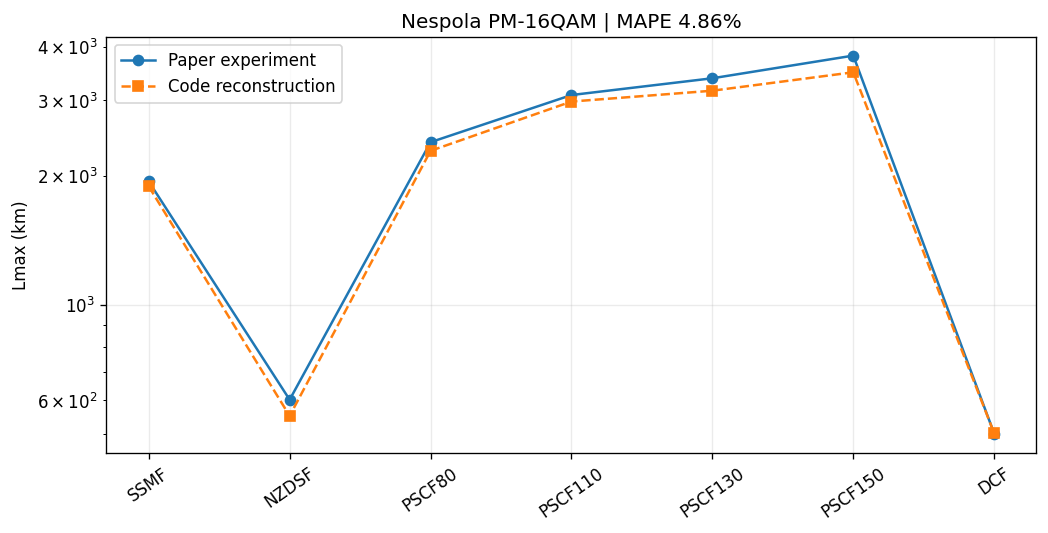

In [7]:
RESULT_NESPOLA = run_nespola()


## 논문 3 — Carena JLT 2012

기본값은 `INPUTS_UNVERIFIED`입니다. 검증된 CSV를 넣을 때만 실행합니다.

참조 CSV: `panel,modulation,marker_label,spectral_efficiency,paper_value`
예측 CSV: 같은 키 + `code_value`

In [8]:
RESULT_CARENA = run_carena(CARENA_REFERENCE_CSV, CARENA_PREDICTION_CSV)


{'paper': 'Carena JLT 2012', 'validation_type': 'INPUTS_UNVERIFIED', 'MAPE_percent': None, 'reason': 'Exact panel inputs, BER/FEC threshold and marker outputs are required.'}


## 논문 4 — Petrovich HCF geometry

nominal geometry로 Raw 분산을 계산하고 FEM과 비교합니다. 손실 proxy는 총손실과 직접적인 정확도 비교를 하지 않습니다.


03_petrovich_dispersion
 wavelength_nm  paper_FEM_D  code_raw_D  absolute_error_pct
        1310.0          2.1    2.665145           26.911661
        1550.0          3.2    3.331737            4.116794
        1700.0          3.7    3.797515            2.635537

04_petrovich_loss_audit
 wavelength_nm  paper_total_loss_db_km  code_raw_leakage_proxy_db_km  absolute_error_pct
        1310.0                   0.128                 156381.450860        1.221729e+08
        1550.0                   0.091                 126020.874408        1.384844e+08


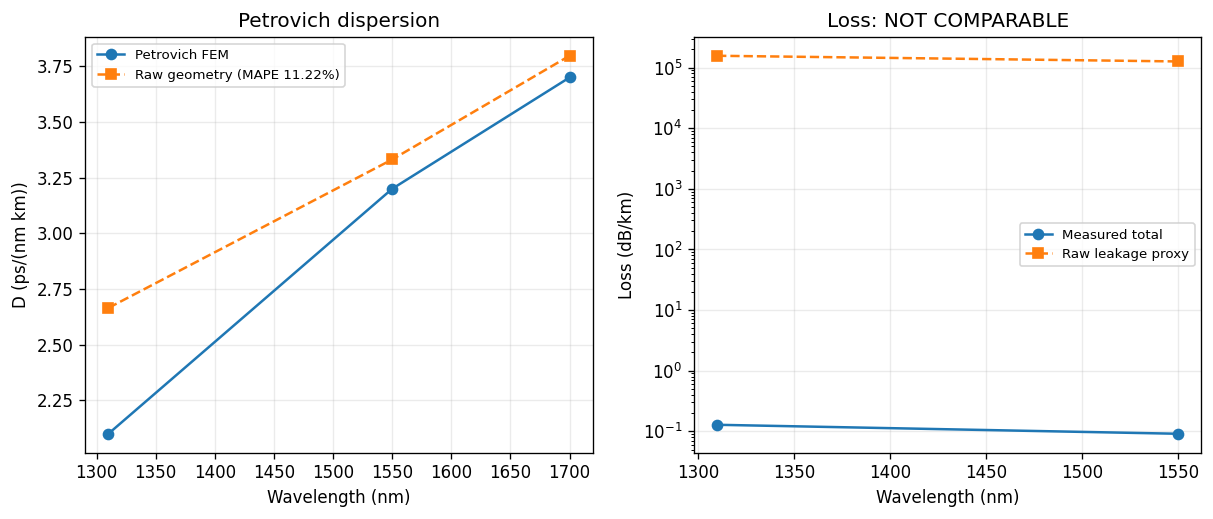

In [9]:
RESULT_PETROVICH = run_petrovich()


## 사용자 입력 기반 CUSTOM HCF

`CUSTOM_INPUTS`만 수정해 다른 HCF/광섬유 조건을 계산합니다.


06_custom_launch_sweep
 launch_dBm    SNR_dB   GSNR_dB  throughput_Tbps
      -20.0  2.782679  2.915317        26.248433
      -19.8  2.976527  3.115317        26.975127
      -19.6  3.170094  3.315317        27.711696
      -19.4  3.363369  3.515317        28.457879
      -19.2  3.556337  3.715317        29.213408
      -19.0  3.748986  3.915317        29.978005
      -18.8  3.941302  4.115317        30.751382
      -18.6  4.133271  4.315317        31.533243
      -18.4  4.324877  4.515317        32.323287
      -18.2  4.516104  4.715317        33.121202
      -18.0  4.706938  4.915317        33.926672
      -17.8  4.897359  5.115317        34.739374
      -17.6  5.087352  5.315317        35.558979
      -17.4  5.276898  5.515317        36.385155
      -17.2  5.465979  5.715317        37.217561
      -17.0  5.654574  5.915317        38.055857
      -16.8  5.842663  6.115317        38.899695
      -16.6  6.030226  6.315317        39.748726
      -16.4  6.217241  6.515317        40.602

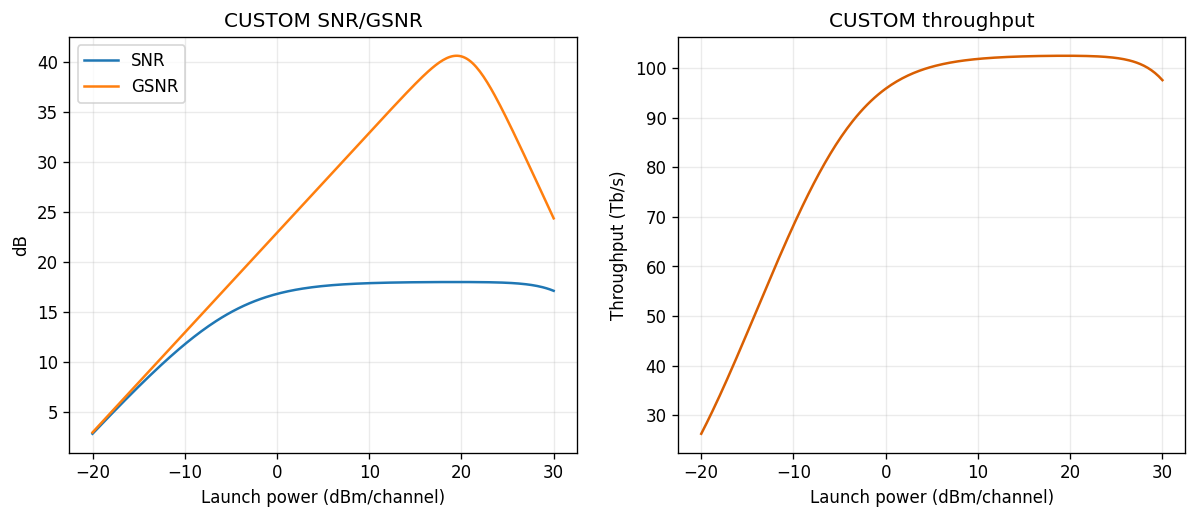

In [10]:
RESULT_CUSTOM = run_custom(CUSTOM_INPUTS)


## 논문별 최종 요약

In [11]:
REPORT_SUMMARY=pd.DataFrame([
 {"paper":RESULT_POGGIOLINI["paper"],"validation_type":RESULT_POGGIOLINI["validation_type"],"MAPE_percent":RESULT_POGGIOLINI["MAPE_percent"]},
 {"paper":RESULT_NESPOLA["paper"],"validation_type":RESULT_NESPOLA["validation_type"],"MAPE_percent":RESULT_NESPOLA["MAPE_percent"]},
 {"paper":RESULT_CARENA["paper"],"validation_type":RESULT_CARENA["validation_type"],"MAPE_percent":RESULT_CARENA.get("MAPE_percent")},
 {"paper":RESULT_PETROVICH["paper"],"validation_type":RESULT_PETROVICH["validation_type"],"MAPE_percent":RESULT_PETROVICH["MAPE_percent"]},
 {"paper":"CUSTOM","validation_type":"CUSTOM","MAPE_percent":np.nan}
])
save_table("07_paper_by_paper_summary",REPORT_SUMMARY)
print("Paper-by-paper report completed.")



07_paper_by_paper_summary
          paper                                validation_type  MAPE_percent
Poggiolini 2012                                 EQUATION_CHECK      2.897742
   Nespola 2014                        INPUT_BASED_INDEPENDENT      4.863463
Carena JLT 2012                              INPUTS_UNVERIFIED           NaN
 Petrovich 2025 RAW_GEOMETRY_INDEPENDENT / LOSS_LAYER_MISMATCH     11.221330
         CUSTOM                                         CUSTOM           NaN
Paper-by-paper report completed.


## 5. 독립성·연구 활용 판정

- `###`: Eq.13과 코드식의 이론식 일치성 확인이며 실험 독립검증은 아닙니다.
- `$$$`: 논문 fiber/system 입력을 이용한 출력 재계산입니다. Lmax는 피팅하지 않습니다.
- `%%%`: 정확한 동일 입력 CSV가 없으면 계산하지 않습니다. 그림을 임의로 digitize하지 않습니다.
- `@@@`: nominal geometry 기반 Raw 분산은 독립 비교입니다. 손실 proxy는 Petrovich의 총손실과 물리적 층이 다르므로 정확도 오차로 해석하지 않습니다.
- `CUSTOM`: HCF geometry를 GN 시스템 계산에 연결하는 연구용 screening 모델입니다. 최종 논문 결과에는 full-vector FEM의 complex (n_{eff}), 측정 총손실, (A_{eff}), (gamma), SSFM/실험 비교가 필요합니다.